<a href="https://colab.research.google.com/github/sangramshitole07/AML/blob/main/AML_preprocessing_bestseller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Import necessary libraries
import numpy as np
import pandas as pd

In [10]:
# Upload the dataset from local machine
from google.colab import files

uploaded = files.upload()

# Read the uploaded CSV file into a pandas DataFrame
import pandas as pd

df = pd.read_csv("bestsellers.csv")

# Display the first 5 rows of the DataFrame
df.head()

Saving bestsellers.csv to bestsellers (1).csv


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350.0,8.0,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052.0,22.0,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979.0,15.0,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424.0,6.0,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665.0,12.0,2019,Non Fiction


In [11]:
# Display concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  548 non-null    float64
 3   Reviews      549 non-null    float64
 4   Price        549 non-null    float64
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 30.2+ KB


In [12]:
# Check for missing values in each column and sum them up
df.isnull().sum()

,0
Name,0
Author,0
User Rating,2
Reviews,1
Price,1
Year,0
Genre,0


In [13]:
# Print the number of duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# If duplicate rows exist, remove them and print a confirmation message
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")

# Display the first 5 rows of the DataFrame after checking/removing duplicates
display(df.head())

Number of duplicate rows: 0


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350.0,8.0,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052.0,22.0,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979.0,15.0,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424.0,6.0,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665.0,12.0,2019,Non Fiction


In [14]:
# Display the number of unique book names before cleaning
print("unique values in Name before cleaning : ")
print(df['Name'].nunique())

# Display the top 10 most frequent book names before cleaning
print(df['Name'].value_counts().head(10))

unique values in Name before cleaning : 
351
Name
Publication Manual of the American Psychological Association, 6th Edition            10
StrengthsFinder 2.0                                                                   9
Oh, the Places You'll Go!                                                             8
The Very Hungry Caterpillar                                                           7
The 7 Habits of Highly Effective People: Powerful Lessons in Personal Change          7
The Four Agreements: A Practical Guide to Personal Freedom (A Toltec Wisdom Book)     6
Jesus Calling: Enjoying Peace in His Presence (with Scripture References)             6
The Official SAT Study Guide                                                          5
The 5 Love Languages: The Secret to Love That Lasts                                   5
Laugh-Out-Loud Jokes for Kids                                                         5
Name: count, dtype: int64


In [15]:
# Convert 'Name' column to lowercase and remove leading/trailing whitespace
df['Name'] = df['Name'].str.lower().str.strip()

# Display the number of unique book names after cleaning
print('Unique values in Name after cleaning:')
print(df['Name'].nunique())

# Display the top 10 most frequent book names after cleaning
print(df['Name'].value_counts().head(10))

Unique values in Name after cleaning:
350
Name
publication manual of the american psychological association, 6th edition            10
the 5 love languages: the secret to love that lasts                                  10
strengthsfinder 2.0                                                                   9
oh, the places you'll go!                                                             8
the very hungry caterpillar                                                           7
the 7 habits of highly effective people: powerful lessons in personal change          7
the four agreements: a practical guide to personal freedom (a toltec wisdom book)     6
jesus calling: enjoying peace in his presence (with scripture references)             6
the five dysfunctions of a team: a leadership fable                                   5
wonder                                                                                5
Name: count, dtype: int64


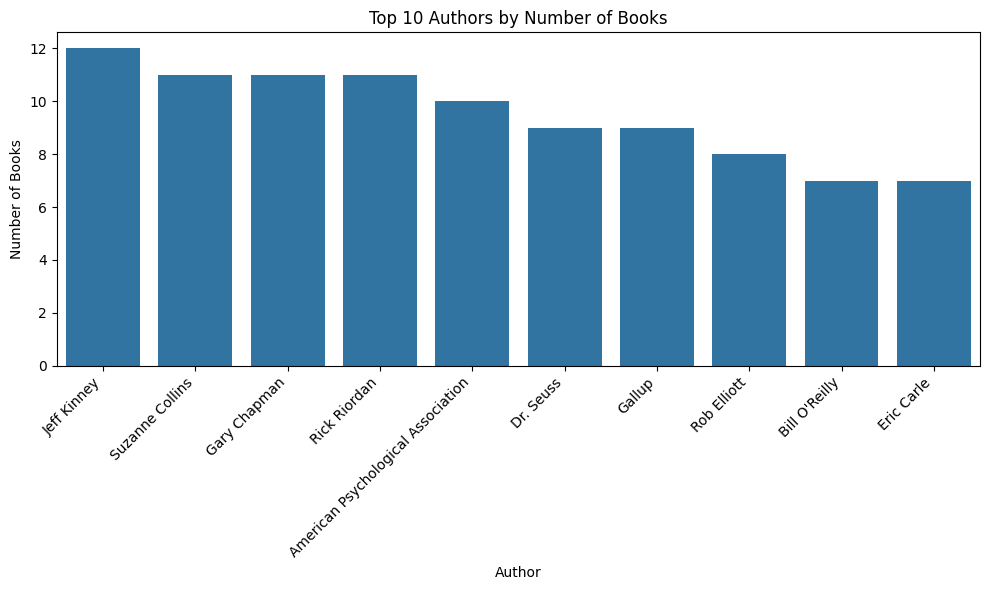

In [16]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 authors by their count in the dataset
top_10_authors = df['Author'].value_counts().head(10)

# Create a figure for the plot with a specified size
plt.figure(figsize=(10, 6))

# Create a bar plot of the top 10 authors and their book counts
sns.barplot(x=top_10_authors.index, y=top_10_authors.values)

# Add title and labels for better readability
plt.title('Top 10 Authors by Number of Books')
plt.xlabel('Author')
plt.ylabel('Number of Books')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for long names
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot